# Results summary final CAPSTONE CALL

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, h5py

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))
import analyze_l3_stratified as l3
from pneumophonic_analysis.paired_features import PairedFeatureExtractor
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

PAIRED = REPO / "data_target" / "healthy_subjects" / "paired"
META = REPO / "data_root" / "healthy_subjects" / "subjects_metadata.csv"
_sids = sorted({f.stem.split('_', 1)[0] for f in PAIRED.glob('*.h5')})
ALIAS = {s: f"S{i+1:02d}" for i, s in enumerate(_sids)}
print("corpus:", len(list(PAIRED.glob('*.h5'))), "recordings,", len(_sids), "subjects")

corpus: 550 recordings, 39 subjects


## 1. FRC : Above vs Bellow 
When a subject sustains a vowel the lung empties and at some point crosses the resting end-expiratory volume, the functional residual capacity (FRC).\
We measure how strongly each signal changes from **above FRC to below FRC** using **Cohen's d**.\
\
\
Anlayzed tasks : **a_2, a_3**

In [2]:
seg = l3.collect_paired_segments(PAIRED, l3.load_metadata(META), tasks=['a_2', 'a_3'])
seg = l3.assign_demographic_group(seg.dropna(subset=['sex', 'age']), 55)
strata = ['All', 'Male', 'Female', 'Young', 'Elder', 'YM', 'YF', 'EM', 'EF']
def dvals(feat):
    return l3.stratified_effect_sizes(seg, feat).set_index('stratum').reindex(strata)['cohen_d']
f0d, rcd = dvals('f0'), dvals('pct_rc')
x = np.arange(len(strata)); w = 0.4

2026-06-16 09:08:53,675 - analyze_l3_stratified - INFO - Found 550 paired HDF5 files in C:\Users\Matéo\OneDrive\Documents\GitHub\pneumophonic_pipeline\data_target\healthy_subjects\paired


2026-06-16 09:09:05,747 - analyze_l3_stratified - INFO - Segments: kept=59  skipped_task=476  skipped_split=4  skipped_voiced=11


2026-06-16 09:09:05,756 - analyze_l3_stratified - INFO -   FRC crossing method: {'genuine': 52, 'midpoint': 7}


2026-06-16 09:09:05,771 - analyze_l3_stratified - WARNING - No metadata for 1 subject(s): ['CaBl']. They will be excluded from stratified analysis.


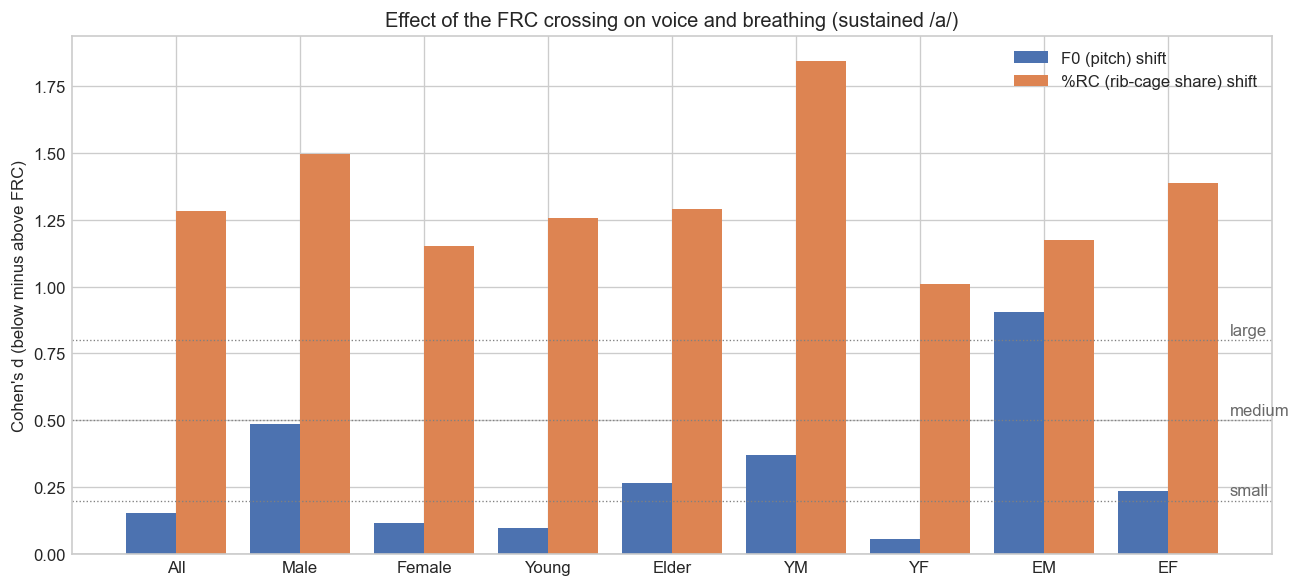

All subjects: F0 d = 0.15 (negligible), %RC d = 1.28 (large)


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, f0d, w, label='F0 (pitch) shift', color='#4c72b0')
ax.bar(x + w/2, rcd, w, label='%RC (rib-cage share) shift', color='#dd8452')
for d, lab in [(0.2, 'small'), (0.5, 'medium'), (0.8, 'large')]:
    ax.axhline(d, color='gray', ls=':', lw=0.8); ax.text(len(x) - 0.5, d + 0.02, lab, fontsize=10, color='dimgray')
ax.axhline(0, color='black', lw=0.7); ax.set_xticks(x); ax.set_xticklabels(strata)
ax.set_ylabel("Cohen's d (below minus above FRC)")
ax.set_title("Effect of the FRC crossing on voice and breathing (sustained /a/)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"All subjects: F0 d = {f0d['All']:.2f} (negligible), %RC d = {rcd['All']:.2f} (large)")

**Observations.** \
The rib-cage contribution `%RC` changes a lot at the FRC crossing, a large effect (**d ~ 1.3**) that is consistent in every group -> **physiological behaviour of active expiration : relaxation of diaphram + expiratory muscles : intercostals**\
\
The pitch `F0` barely changes, a negligible effect (**d ~ 0.15**), except in elderly males.\
\
The FRC crossing seems to be marked by which part of the chest drives the breath, not by a pitch change (previous **f_0,shift**).\
Previous results and statement on **f_0,shift** were caused by the leak of \a_7 Glide Vocal data in the data used in this case study, we had to find this error to sort out those results.

## 2. One breath - 3 domains visualization

A single vocal glide from one subject, shown three ways: **the chest-wall volume (CW) crossing FRC** (left), the **loudness of the voice** (middle), and the **sound spectrum with the pitch track** (right).\
The dashed line marks the FRC crossing.

In [4]:
from analyze_l3_stratified import find_genuine_frc_crossing, find_frc_crossing_index
H5 = PAIRED / "MaMa_a_7.h5"
df, meta = PairedFeatureExtractor.load_hdf5(H5)
t = df['time'].values; f0 = df['f0'].where(df['voiced'] == 1.0).values
amp = (df['rms_audio'] if 'rms_audio' in df.columns else df['energy']).values
dvf = df['delta_vcw_frc'].values if 'delta_vcw_frc' in df.columns else df['delta_vcw'].values
ci = find_genuine_frc_crossing(dvf)
if ci is None: ci = find_frc_crossing_index(df['delta_vcw'].values)
tc = t[ci]; fa = np.nanmean(f0[:ci]); fb = np.nanmean(f0[ci:])
with h5py.File(H5, 'r') as f: S = f['stft'][:]; sr = int(f.attrs['sr_audio'])
freqs = np.linspace(0, sr/2, S.shape[0]); km = np.searchsorted(freqs, 1500); Sdb = 20*np.log10(S[:km] + 1e-6)
alias = ALIAS.get(meta['subject_id'], meta['subject_id'])


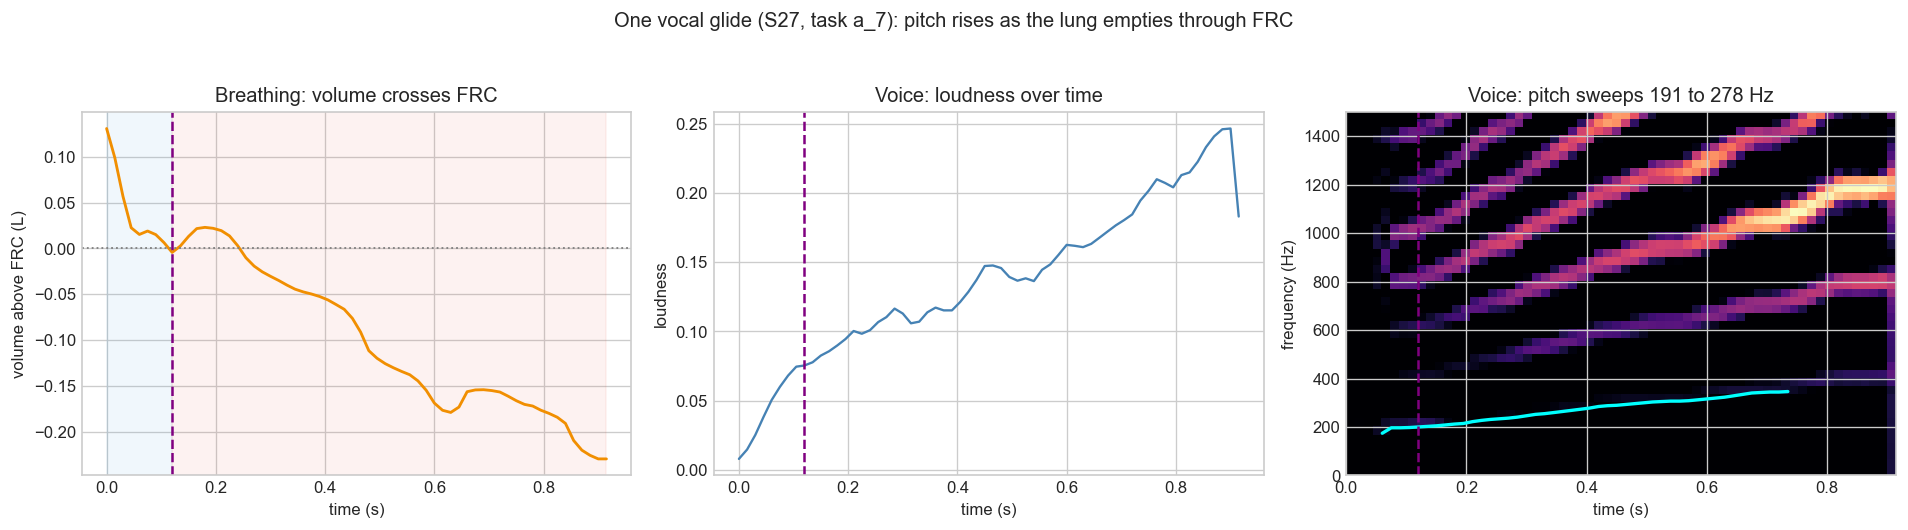

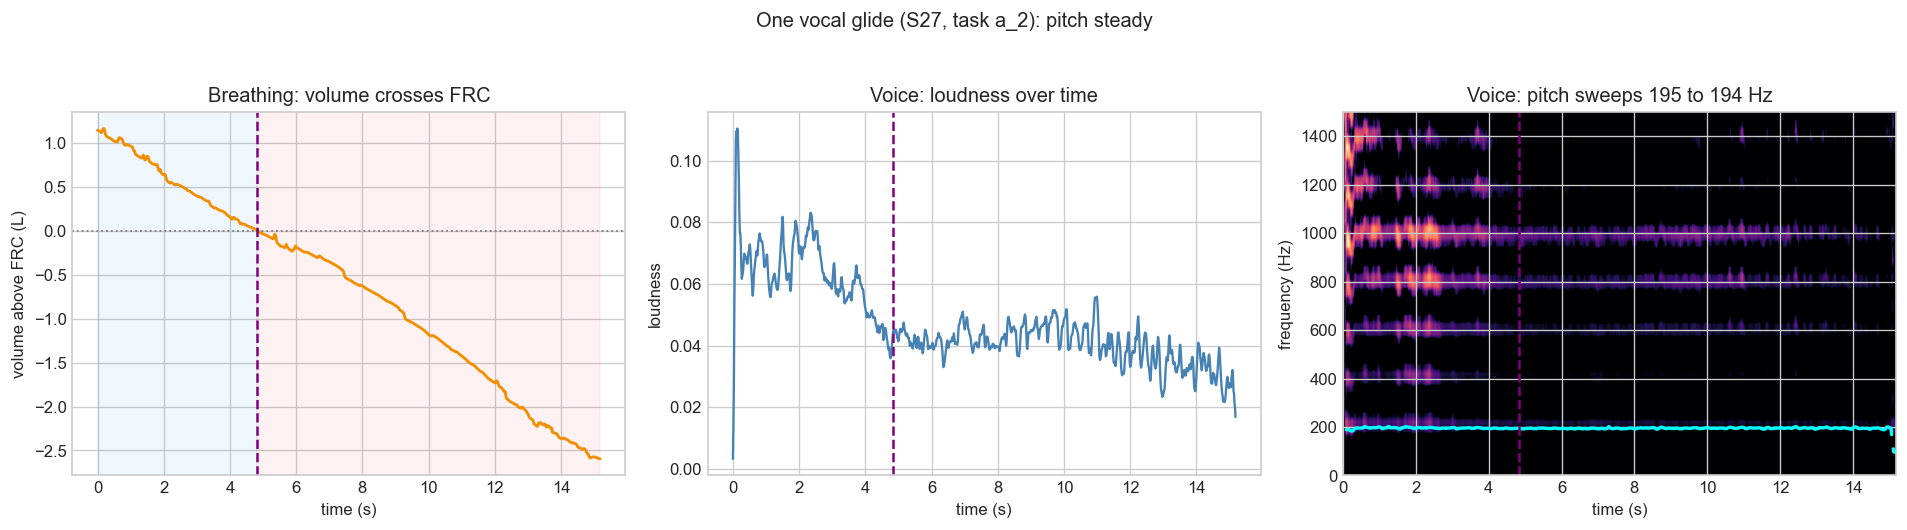

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
a = ax[0]; a.plot(t, dvf, color='#F18F01', lw=1.7); a.axhline(0, color='gray', ls=':', lw=1.1)
a.axvline(tc, color='purple', lw=1.5, ls='--'); a.axvspan(t[0], tc, color='#3498DB', alpha=.07); a.axvspan(tc, t[-1], color='#E74C3C', alpha=.07)
a.set_xlabel('time (s)'); a.set_ylabel('volume above FRC (L)'); a.set_title('Breathing: volume crosses FRC')
a = ax[1]; a.plot(t, amp, color='steelblue', lw=1.4); a.axvline(tc, color='purple', lw=1.5, ls='--')
a.set_xlabel('time (s)'); a.set_ylabel('loudness'); a.set_title('Voice: loudness over time')
a = ax[2]; a.imshow(Sdb, origin='lower', aspect='auto', extent=[t[0], t[-1], 0, 1500], cmap='magma', vmin=Sdb.max()-70, vmax=Sdb.max())
a.plot(t, f0, color='cyan', lw=2); a.axvline(tc, color='purple', lw=1.5, ls='--')
a.set_ylim(0, 1500); a.set_xlabel('time (s)'); a.set_ylabel('frequency (Hz)'); a.set_title(f'Voice: pitch sweeps {fa:.0f} to {fb:.0f} Hz')
fig.suptitle(f'One vocal glide ({alias}, task a_7): pitch rises as the lung empties through FRC', y=1.04)
plt.tight_layout()
plt.show()

# PSEUDO - SUBPLOT WITH SUSTAINED PITCH A_2 VS A_7
H5 = PAIRED / "MaMa_a_2.h5"
df, meta = PairedFeatureExtractor.load_hdf5(H5)
t = df['time'].values; f0 = df['f0'].where(df['voiced'] == 1.0).values
amp = (df['rms_audio'] if 'rms_audio' in df.columns else df['energy']).values
dvf = df['delta_vcw_frc'].values if 'delta_vcw_frc' in df.columns else df['delta_vcw'].values
ci = find_genuine_frc_crossing(dvf)
if ci is None: ci = find_frc_crossing_index(df['delta_vcw'].values)
tc = t[ci]; fa = np.nanmean(f0[:ci]); fb = np.nanmean(f0[ci:])
with h5py.File(H5, 'r') as f: S = f['stft'][:]; sr = int(f.attrs['sr_audio'])
freqs = np.linspace(0, sr/2, S.shape[0]); km = np.searchsorted(freqs, 1500); Sdb = 20*np.log10(S[:km] + 1e-6)
alias = ALIAS.get(meta['subject_id'], meta['subject_id'])
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
a = ax[0]; a.plot(t, dvf, color='#F18F01', lw=1.7); a.axhline(0, color='gray', ls=':', lw=1.1)
a.axvline(tc, color='purple', lw=1.5, ls='--'); a.axvspan(t[0], tc, color='#3498DB', alpha=.07); a.axvspan(tc, t[-1], color='#E74C3C', alpha=.07)
a.set_xlabel('time (s)'); a.set_ylabel('volume above FRC (L)'); a.set_title('Breathing: volume crosses FRC')
a = ax[1]; a.plot(t, amp, color='steelblue', lw=1.4); a.axvline(tc, color='purple', lw=1.5, ls='--')
a.set_xlabel('time (s)'); a.set_ylabel('loudness'); a.set_title('Voice: loudness over time')
a = ax[2]; a.imshow(Sdb, origin='lower', aspect='auto', extent=[t[0], t[-1], 0, 1500], cmap='magma', vmin=Sdb.max()-70, vmax=Sdb.max())
a.plot(t, f0, color='cyan', lw=2); a.axvline(tc, color='purple', lw=1.5, ls='--')
a.set_ylim(0, 1500); a.set_xlabel('time (s)'); a.set_ylabel('frequency (Hz)'); a.set_title(f'Voice: pitch sweeps {fa:.0f} to {fb:.0f} Hz')
fig.suptitle(f'One vocal glide ({alias}, task a_2): pitch steady', y=1.04)
plt.tight_layout(); plt.show()

**Descri.**: same subject, task a_7 (glide) and a_2(sust pitch)\


## 3. Acoustic feature correlations across the entire population

Before the multivariate models we mapped the plain pairwise correlations between the audio and the breathing features.\
The results stayed modest.\
Three views are shown below, drawn from the correlation work in notebooks n°2 to n°4.

**Within one recording.** The correlation matrix of the main features on the voiced frames of a single sustained /a/ (as in notebook n°2).

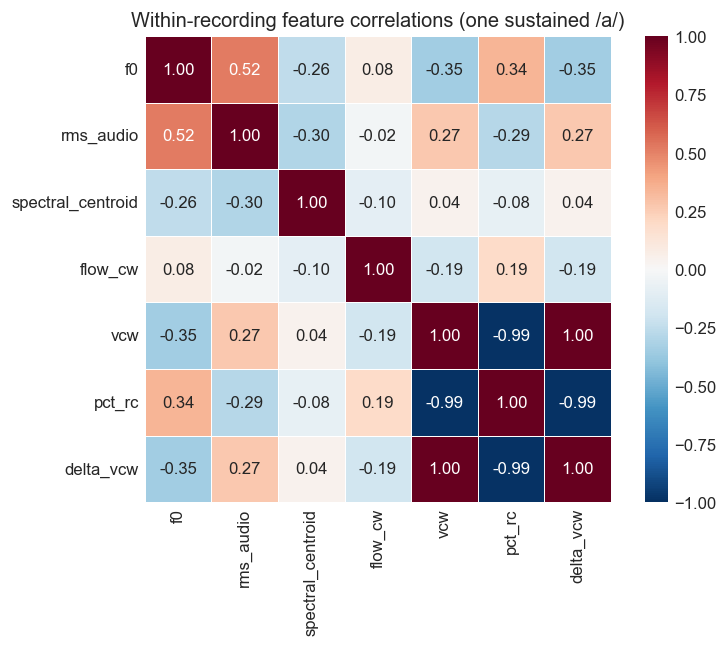

In [6]:
import seaborn as sns
H5a = next(f for f in sorted(PAIRED.glob('*_a_2.h5')))
dfa, _ = PairedFeatureExtractor.load_hdf5(H5a)
v = dfa[dfa['voiced'] == 1.0]
cols = [c for c in ['f0', 'rms_audio', 'spectral_centroid', 'flow_cw', 'vcw', 'pct_rc', 'delta_vcw'] if c in v.columns]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(v[cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Within-recording feature correlations (one sustained /a/)')
plt.tight_layout(); plt.show()

**Observations.**\
No strong correlation between audio and respiratory features.\
trivial : strong coupled respiratory features

**Spectral shape (MFCC) against breathing.**\
Mean correlation of the first eight MFCCs with three respiratory features, averaged over 150 recordings.

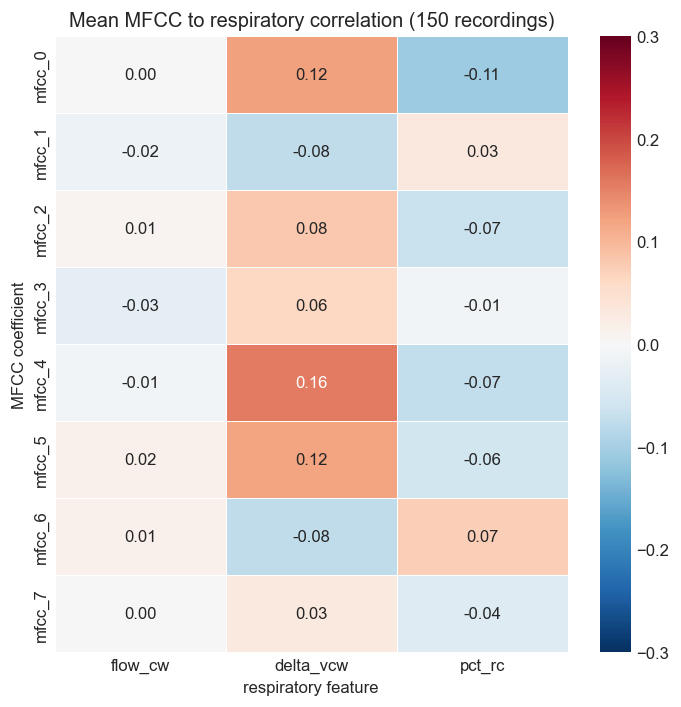

In [7]:
from scipy.stats import pearsonr
mfccs = [f'mfcc_{i}' for i in range(8)]; oeps = ['flow_cw', 'delta_vcw', 'pct_rc']
acc = {(m, o): [] for m in mfccs for o in oeps}
for f in sorted(PAIRED.glob('*.h5'))[:150]:
    try: d, _ = PairedFeatureExtractor.load_hdf5(f)
    except Exception: continue
    vv = d[d['voiced'] == 1.0]
    if len(vv) < 30: continue
    for m in mfccs:
        for o in oeps:
            if m in vv and o in vv:
                x, y = vv[m].values, vv[o].values; k = np.isfinite(x) & np.isfinite(y)
                if k.sum() > 20 and x[k].std() > 1e-9 and y[k].std() > 1e-9:
                    acc[(m, o)].append(pearsonr(x[k], y[k])[0])
M = pd.DataFrame(index=mfccs, columns=oeps, dtype=float)
for (m, o), vals in acc.items(): M.loc[m, o] = (np.nanmean(vals) if vals else np.nan)
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(M.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.5, ax=ax)
ax.set_title('Mean MFCC to respiratory correlation (150 recordings)')
ax.set_xlabel('respiratory feature'); ax.set_ylabel('MFCC coefficient')
plt.tight_layout(); plt.show()

**Observations.**\
The map is mostly pale: **no MFCC correlates strongly with any respiratory feature** (most |r| below 0.2).\
Only the low-order coefficients (overall level) lean away from zero.\
Spectral shape carries little respiratory information beyond what loudness already gives.

**Full task overview.**\
Mean within-recording correlation between each audio feature and each breathing feature, by task.

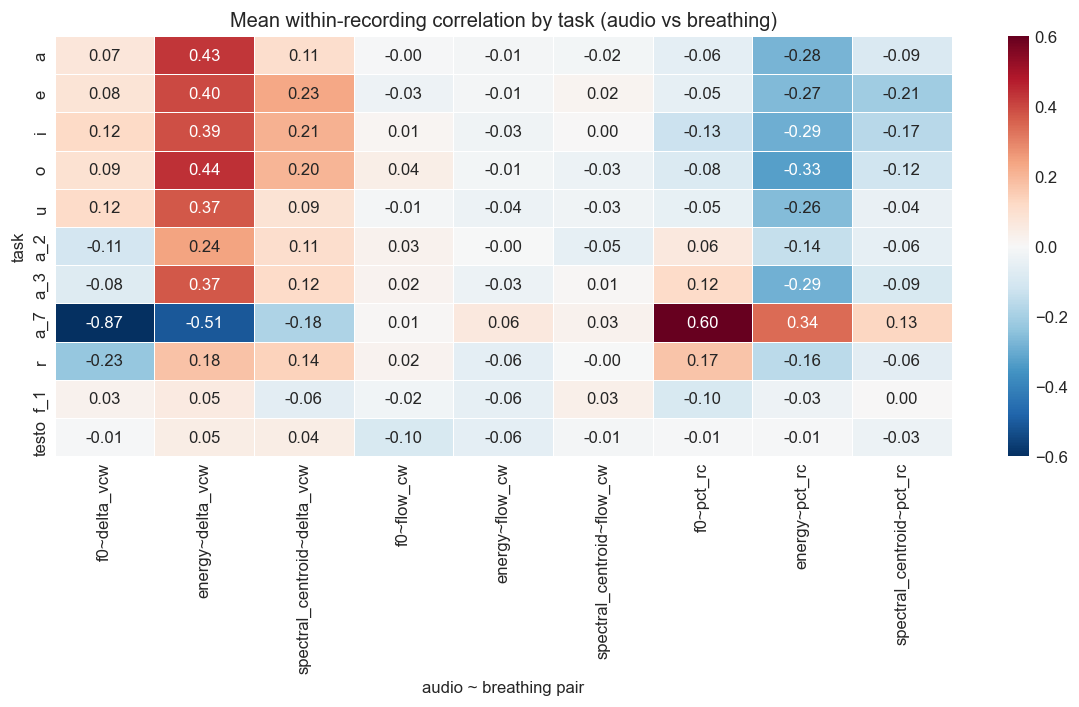

In [8]:
ACO = ['f0', 'energy', 'spectral_centroid']; OE = ['delta_vcw', 'flow_cw', 'pct_rc']
tasks = ['a', 'e', 'i', 'o', 'u', 'a_2', 'a_3', 'a_7', 'r', 'f_1', 'testo']
rows = []
for f in sorted(PAIRED.glob('*.h5')):
    try: d, m = PairedFeatureExtractor.load_hdf5(f)
    except Exception: continue
    if m.get('task_name') not in tasks: continue
    vv = d[d['voiced'] == 1.0]
    if len(vv) < 15: continue
    for a in ACO:
        for o in OE:
            if a in vv and o in vv:
                x, y = vv[a].values, vv[o].values; k = np.isfinite(x) & np.isfinite(y)
                if k.sum() > 15 and x[k].std() > 1e-9 and y[k].std() > 1e-9:
                    rows.append((m['task_name'], f'{a}~{o}', pearsonr(x[k], y[k])[0]))
R = pd.DataFrame(rows, columns=['task', 'pair', 'r'])
piv = (R.groupby(['task', 'pair'])['r'].mean().unstack()
       .reindex(index=[t for t in tasks if t in set(R.task)],
                columns=[f'{a}~{o}' for o in OE for a in ACO]))
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6, linewidths=0.5, ax=ax)
ax.set_title('Mean within-recording correlation by task (audio vs breathing)')
ax.set_xlabel('audio ~ breathing pair'); ax.set_ylabel('task')
plt.tight_layout(); plt.show()

**Observations.**\
Across the steady tasks the **couplings are weak**.\
The pitch with volume correlation is strong and negative only in the glide `a_7`, where the speaker sweeps pitch on purpose.\
This is the result that told us to treat the glide separately and to expect only a modest link elsewhere.

## 4. Can the breathing state be read from the voice alone? And Vice and Versa ?

From the audio of a phonation, can we tell whether the subject is above or below FRC?\
We trained a classifier and report the area under the ROC curve (AUC), where **0.5 is chance** and **1.0 is perfect**.
\
\
\
\
\
\
notes : **Receiver Operating Characteristic (ROC)** is a binary classifier that outputs a score; we sweep the decision threshold from strict to lenient, and at each threshold plot the true‑positive rate (y) against the false‑positive rate (x). The curve traces that trade‑off.

In [9]:
import analyze_frc_classification as clf
get_ipython().run_line_magic("matplotlib", "inline")  # re-assert inline: the analysis scripts set Agg at import

frames, zf = clf.build_labeled_dataset(PAIRED, clf.load_metadata(META))
pooled, _, _ = clf.grouped_auc(frames, zf, 'subject_id')
f0z = [c for c in zf if c.startswith('f0')]
f0only, _, _ = clf.grouped_auc(frames, f0z, 'subject_id')
labels = ['all audio\n(per frame)', 'pitch only\n(per frame)', 'all audio\n(per breath)', 'chance']
vals = [pooled, f0only, 0.96, 0.5]

2026-06-16 09:09:42,222 - analyze_frc_classification - INFO - Labelled dataset: 29224 voiced frames, 34 subjects, below-FRC fraction = 0.52


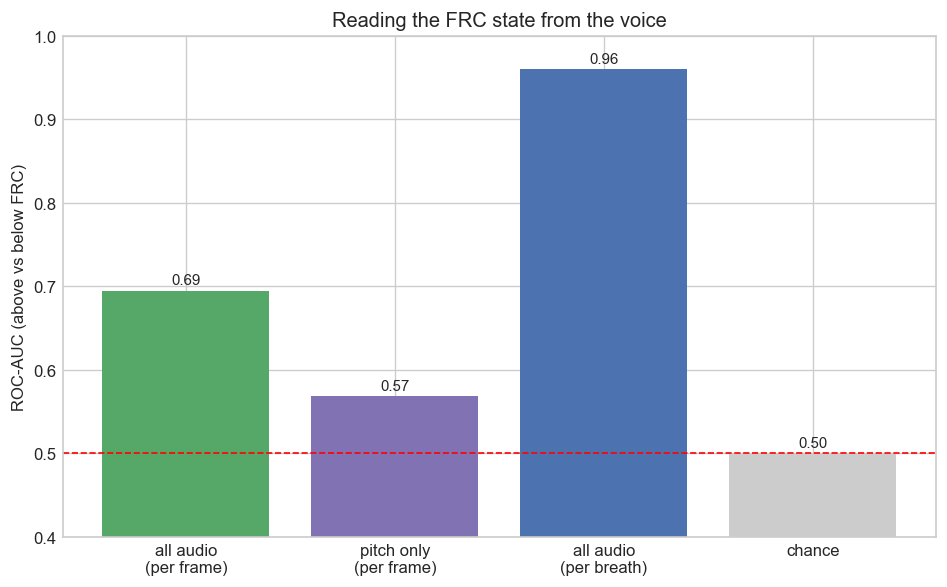

per-frame AUC = 0.69; pitch-only = 0.57; per-breath approx 0.96 (notebook n6)


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(4), vals, color=['#55a868', '#8172b3', '#4c72b0', '#cccccc'])
ax.axhline(0.5, color='red', ls='--', lw=1); ax.set_ylim(0.4, 1.0)
ax.set_xticks(range(4)); ax.set_xticklabels(labels); ax.set_ylabel('ROC-AUC (above vs below FRC)')
ax.set_title('Reading the FRC state from the voice')
for b, v in zip(bars, vals): ax.text(b.get_x() + b.get_width()/2, v + 0.008, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print(f"per-frame AUC = {pooled:.2f}; pitch-only = {f0only:.2f}; per-breath approx 0.96 (notebook n6)")

**Observations** \
From a single frame the voice carries a weak but real signal (**AUC ~ 0.66 to 0.70**).\
It is carried by loudness and spectral level, not by pitch, since using pitch alone is close to chance.\
When frames are pooled to the scale of a whole breath the **AUC rises to ~ 0.96**.\
The respiratory state is a slow, breath-level property that the voice reflects mainly through loudness.\
This is the one positive predictive result of the project.

## 5. Does a multivariate model find a stronger link?

We then combined many audio features at once and measure how strongly they relate to the breathing features, using canonical correlation analysis (**CCA**).\
The grey bars are the correlation measured on the same data used to fit the model.\
The red bars are the honest value measured on data the model did not see.

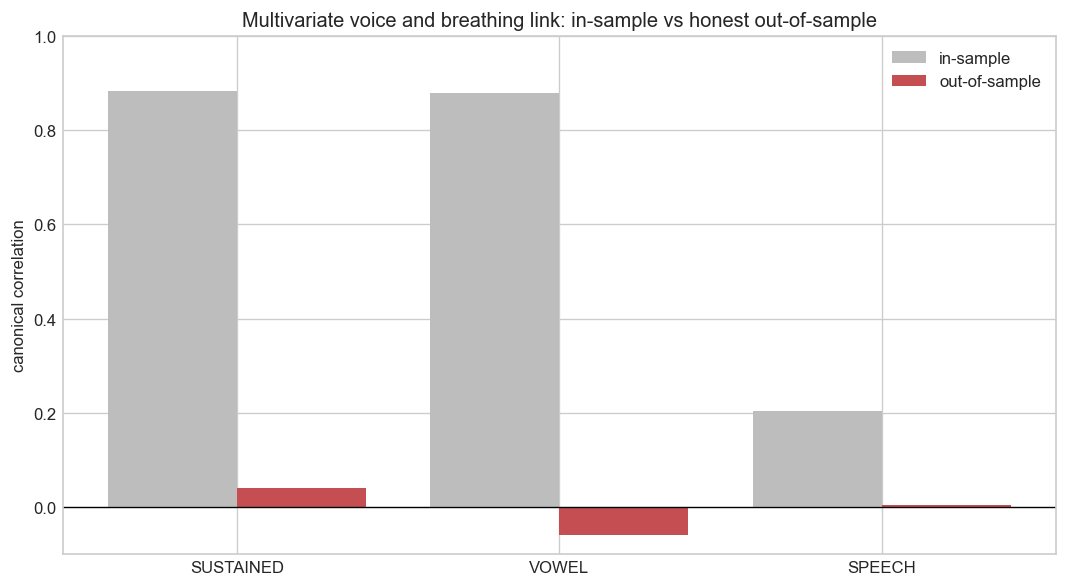

               cca_r_full  cca_r_cv_mean
category_name                           
SUSTAINED           0.883          0.041
VOWEL               0.879         -0.059
SPEECH              0.204          0.003


In [11]:
MV = REPO / "data_target" / "healthy_subjects" / "figures" / "multivariate"
cca = pd.read_csv(MV / "pca_cca" / "PCA_CCA_Subject_Results_healthy_subjects.csv", sep=';')
g = cca.groupby('category_name')[['cca_r_full', 'cca_r_cv_mean']].mean().reindex(['SUSTAINED', 'VOWEL', 'SPEECH'])
x = np.arange(len(g)); w = 0.4
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, g['cca_r_full'], w, label='in-sample', color='#bdbdbd')
ax.bar(x + w/2, g['cca_r_cv_mean'], w, label='out-of-sample', color='#c44e52')
ax.axhline(0, color='black', lw=0.8); ax.set_ylim(-0.1, 1.0)
ax.set_xticks(x); ax.set_xticklabels(g.index); ax.set_ylabel('canonical correlation')
ax.set_title('Multivariate voice and breathing link: in-sample vs honest out-of-sample')
ax.legend(); plt.tight_layout(); plt.show()
print(g.round(3))

**Observations.**\
The in-sample correlation looks strong (**up to ~ 0.9**), but the real out-of-sample value is **close to zero in every task**.\
A predictive **PLS model** points the same way, with **negative out-of-sample scores**.\
A separate pooled analysis across subjects does find a modest average link (**~ 0.39**) carried by loudness, but that is an average tendency across subjects, not a reliable instantaneous predictor inside one recording.

## To summerize

- **Effect size of the FRC shift**:\
   The F0 effect is negligible once the glide is separated, and the reliable per-segment marker is `%RC`, a large effect.
- **Demographic stratification**:\
   `%RC` is large in every group, while F0 is notable only in elderly males.
- **Predict the compartmental state from the voice**:\
  the continuous `%RC` is not predictable frame by frame, but the binary above or below FRC state is readable (AUC about 0.66 per frame, about 0.96 per breath), carried by loudness.
- **Feature engineering and binning before machine learning**: \
  Done as exploratory analysis, which confirmed there is no strong frame-level signal, so heavy models were not deployed.
- **Multivariate methods beyond pairwise correlation**: \
  Done with CCA and predictive PLS. The link is a weak population average, not an out-of-sample predictor.



**Conclusion:** the FRC crossing is a compartmental event (`%RC`, large and consistent), the voice reflects the breathing state mainly through loudness at the breath scale, and the link is a modest population average rather than a tight instantaneous mapping.